# Import packages & Load data

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
stations = pd.read_csv("data/stations.csv")
station_day = pd.read_csv("data/station_day.csv")
city_day = pd.read_csv('data/city_day.csv')
city_hour = pd.read_csv('data/city_hour.csv')

# Merge the dataframes on 'StationId'
merged_data = pd.merge(stations, station_day, on = 'StationId', how='inner')
display(merged_data.head())

,StationId,StationName,City,State,Status,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


# Plot

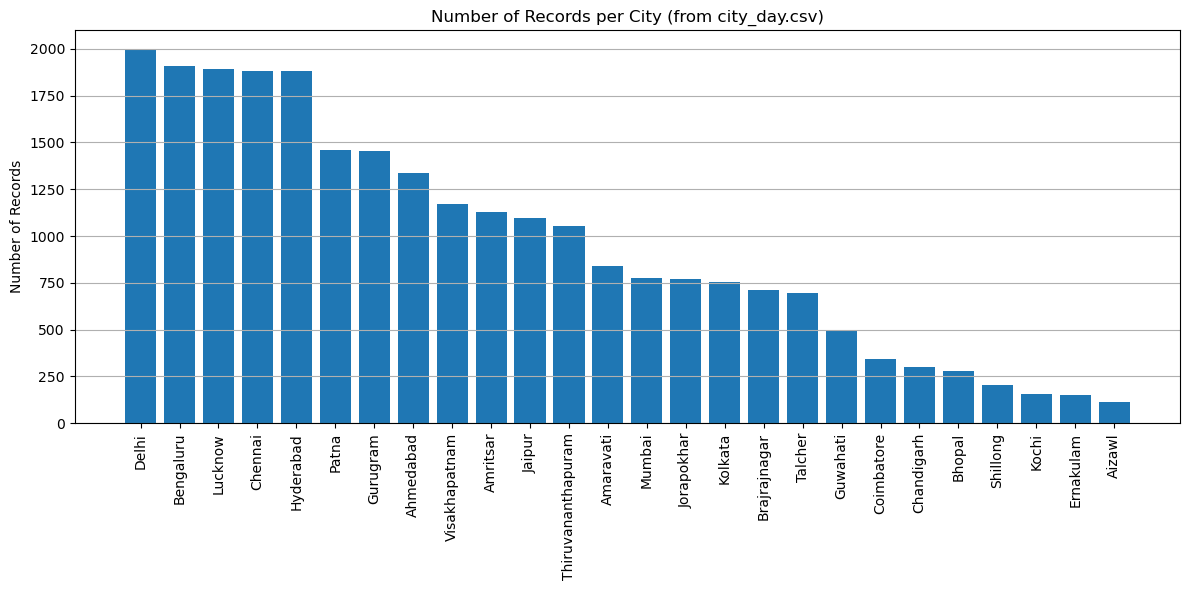

In [ ]:
city_counts = city_day.groupby('City')['AQI'].count().sort_values(ascending=False)

# Create a DataFrame for plotting
city_count_df = city_counts.reset_index()
city_count_df.columns = ['City', 'Number of Records']

# Plot histogram
plt.figure(figsize=(12, 6))
plt.bar(city_count_df['City'], city_count_df['Number of Records'])
plt.title('Number of Records per City (from city_day.csv)')
plt.xlabel('')
plt.ylabel('Number of Records')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

City,Bengaluru,Chennai,Delhi,Hyderabad,Lucknow
Date,,,,,
2015-05-31,102.774194,176.129032,348.580645,133.387097,137.000000
2016-05-31,67.870968,129.258065,268.354839,104.483871,205.000000
2017-05-31,66.967742,121.580645,315.419355,113.193548,252.225806
2018-05-31,92.290323,82.806452,235.322581,98.741935,255.645161
2019-05-31,105.387097,103.612903,235.838710,113.419355,184.096774
2020-05-31,73.161290,78.677419,148.645161,79.354839,119.096774


<Figure size 640x480 with 0 Axes>

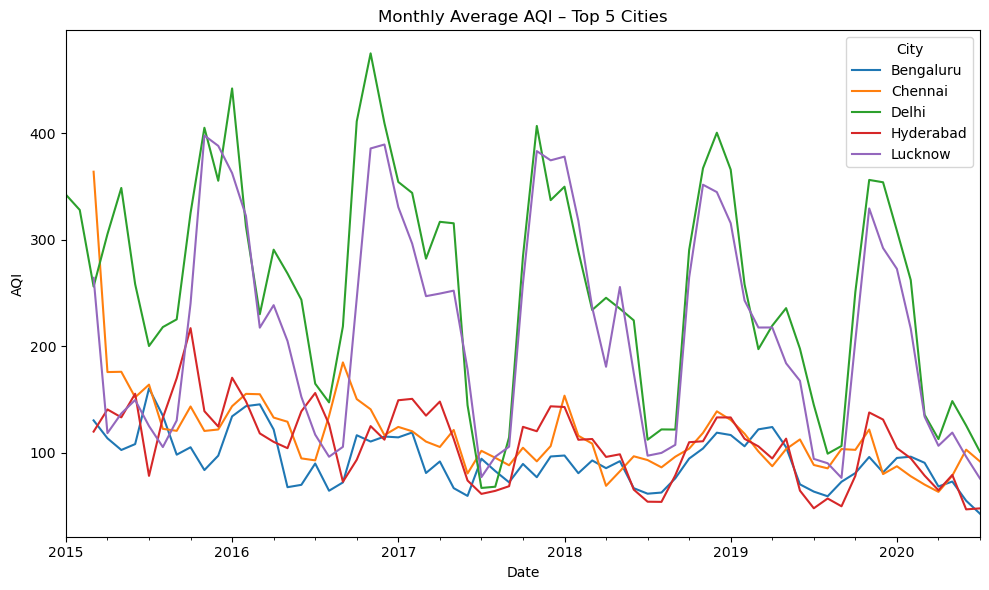

In [20]:
# Preprocess dates and times
city_day['Date'] = pd.to_datetime(city_day['Date'])
city_hour['Datetime'] = pd.to_datetime(city_hour['Datetime'])
city_hour['Hour'] = city_hour['Datetime'].dt.hour

# Plot Monthly average AQI trends for five major cities
# Select top 5 cities with the most non‑null AQI records
non_null_counts = city_day.groupby('City')['AQI'].count().sort_values(ascending=False)
top_cities = non_null_counts.head(5).index.tolist()

ts_data = (
    city_day[city_day['City'].isin(top_cities)]
    .pivot_table(values='AQI', index='Date', columns='City')
    .resample('M')
    .mean()
)

# Filter data for the month of May
ts_data_may = ts_data[ts_data.index.month == 5]
display(ts_data_may)

plt.figure()
ts_data.plot(figsize=(10, 6))
plt.title('Monthly Average AQI – Top 5 Cities')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.tight_layout()

plt.show()


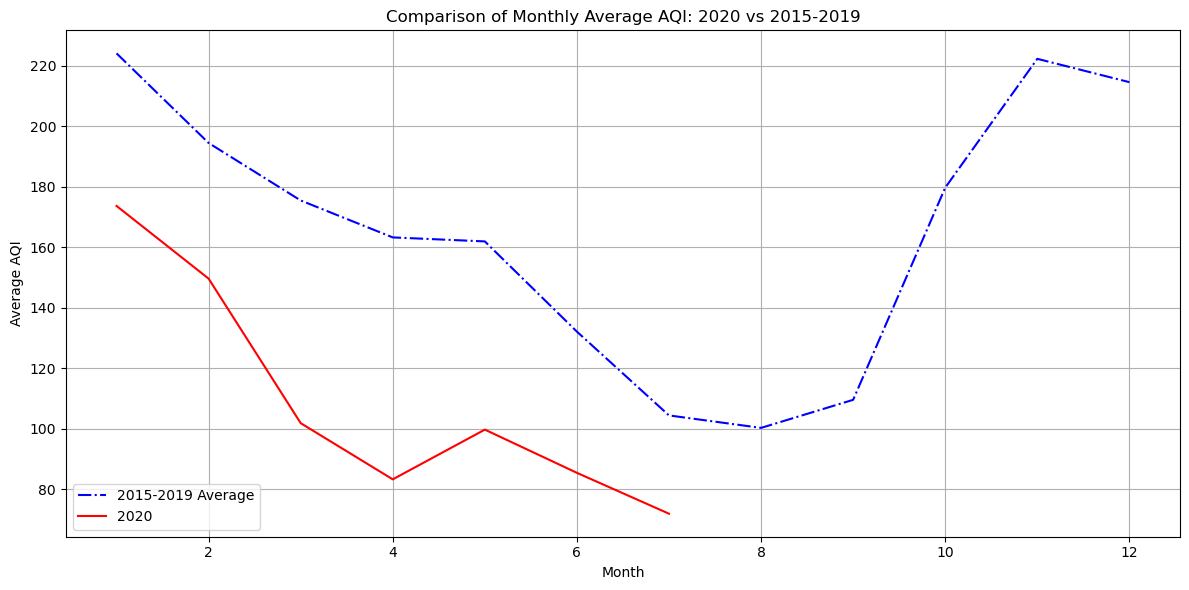

In [21]:
# Analyze the monthly average AQI trend for 2020 compared to other years
# Filter data for 2020
data_2020 = ts_data[ts_data.index.year == 2020]

# Calculate the monthly average for 2015-2019
data_others = ts_data[ts_data.index.year < 2020]
data_others_mean = data_others.groupby(data_others.index.month).mean()

# Plot the comparison chart
plt.figure(figsize=(12, 6))
plt.plot(data_others_mean.index, data_others_mean.mean(axis=1), label='2015-2019 Average', linestyle='-.', color='blue')
plt.plot(data_2020.index.month, data_2020.mean(axis=1), label='2020', color='red')
plt.title('Comparison of Monthly Average AQI: 2020 vs 2015-2019')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

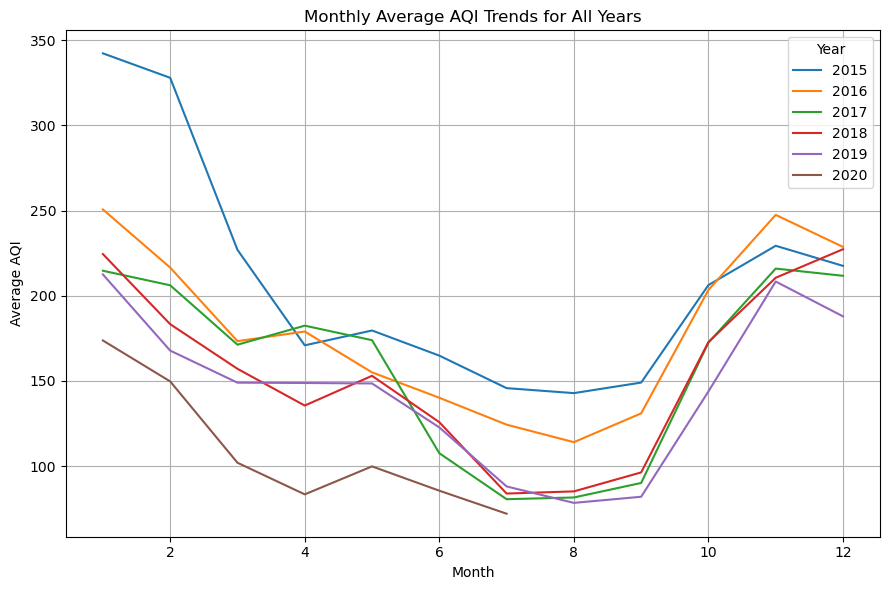

In [22]:
# Plot monthly average AQI trends for all years and overlay them
plt.figure(figsize=(9, 6))

# Loop through each year in the dataset
for year in ts_data.index.year.unique():
    data_year = ts_data[ts_data.index.year == year]
    plt.plot(data_year.index.month, data_year.mean(axis=1), label=str(year))

# Add labels, title, and legend
plt.title('Monthly Average AQI Trends for All Years')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.legend(title='Year', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

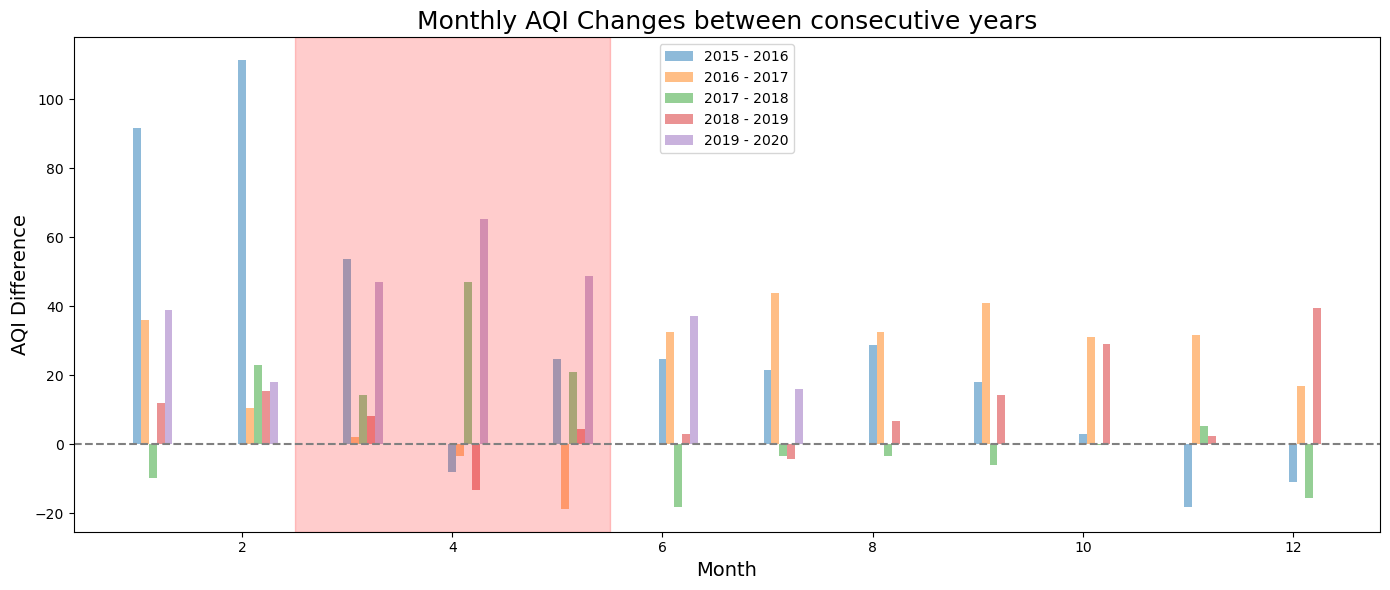

In [ ]:
ts_data.index = pd.to_datetime(ts_data.index)
plt.figure(figsize=(14, 6))

for year in ts_data.index.year.unique():
    if year == 2020:
        continue
    next_year = year + 1
    data_year = ts_data[ts_data.index.year == year]
    data_next_year = ts_data[ts_data.index.year == next_year]

    # Calculate the monthly average AQI for the current year and the next year
	# and the difference between them
    monthly_avg_year = data_year.groupby(data_year.index.month).mean().mean(axis=1)
    monthly_avg_next_year = data_next_year.groupby(data_next_year.index.month).mean().mean(axis=1)
    diff = monthly_avg_year - monthly_avg_next_year

    plt.bar(monthly_avg_year.index + (year - ts_data.index.year.min()) * 0.075, diff, width=0.075, label=f'{year} - {next_year}', alpha=0.5)

# Add labels, title, and legend
plt.axvspan(3 - 0.5, 5 + 0.5, color='red', alpha=0.2)

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Month', fontsize=14)
plt.ylabel('AQI Difference', fontsize=14)
plt.title('Monthly AQI Changes between consecutive years', fontsize=18)
plt.legend()
plt.tight_layout()
plt.show()

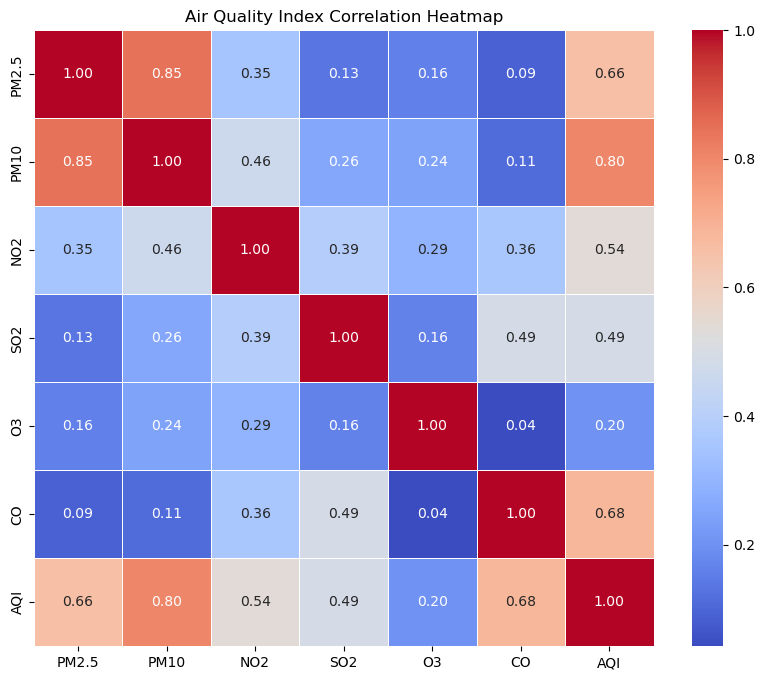

In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO', 'AQI']
correlation = city_day[pollutants].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Air Quality Index Correlation Heatmap')
plt.show()

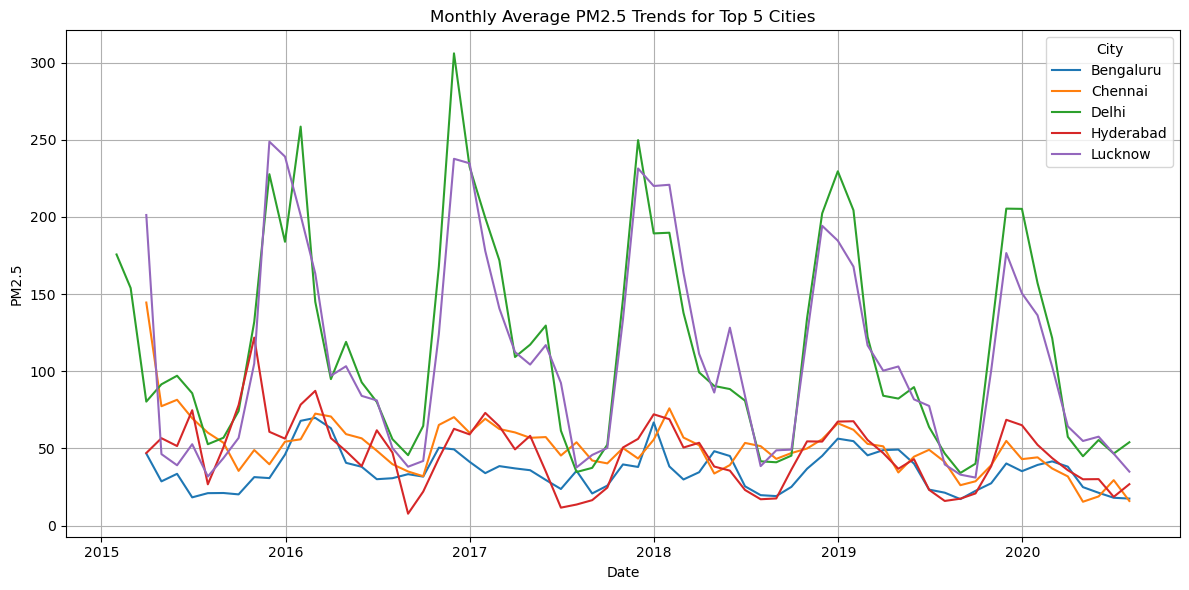

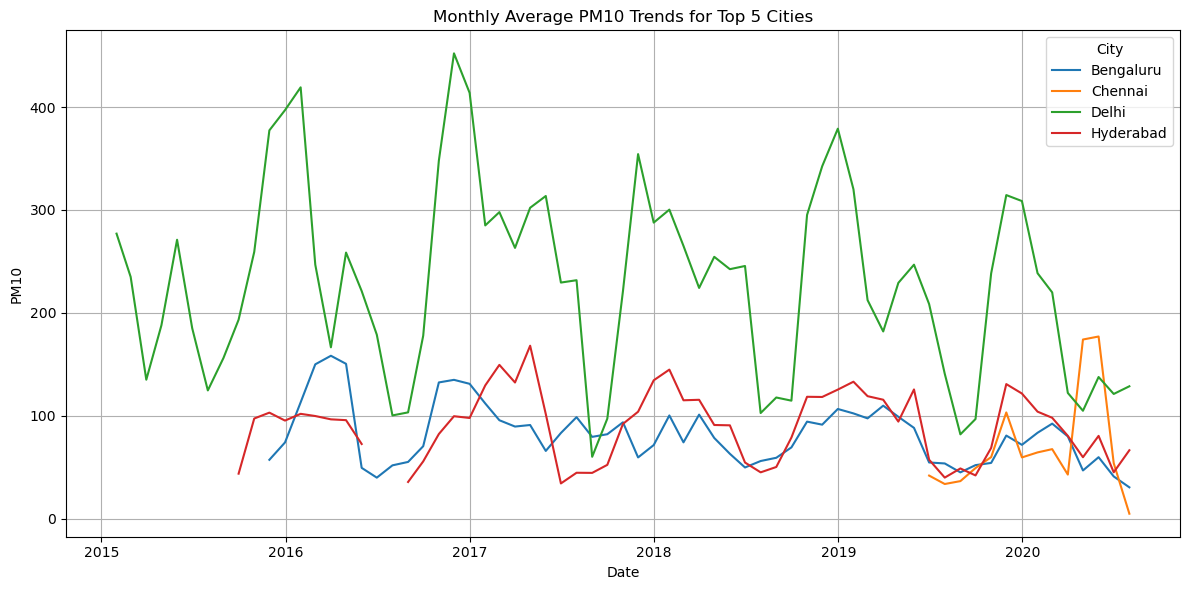

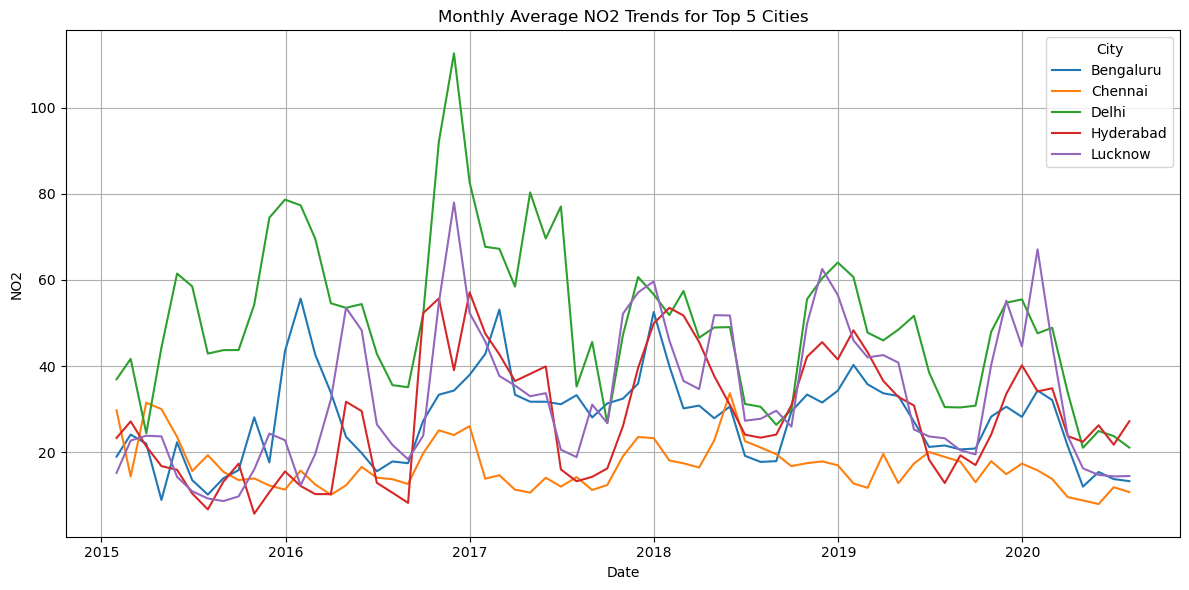

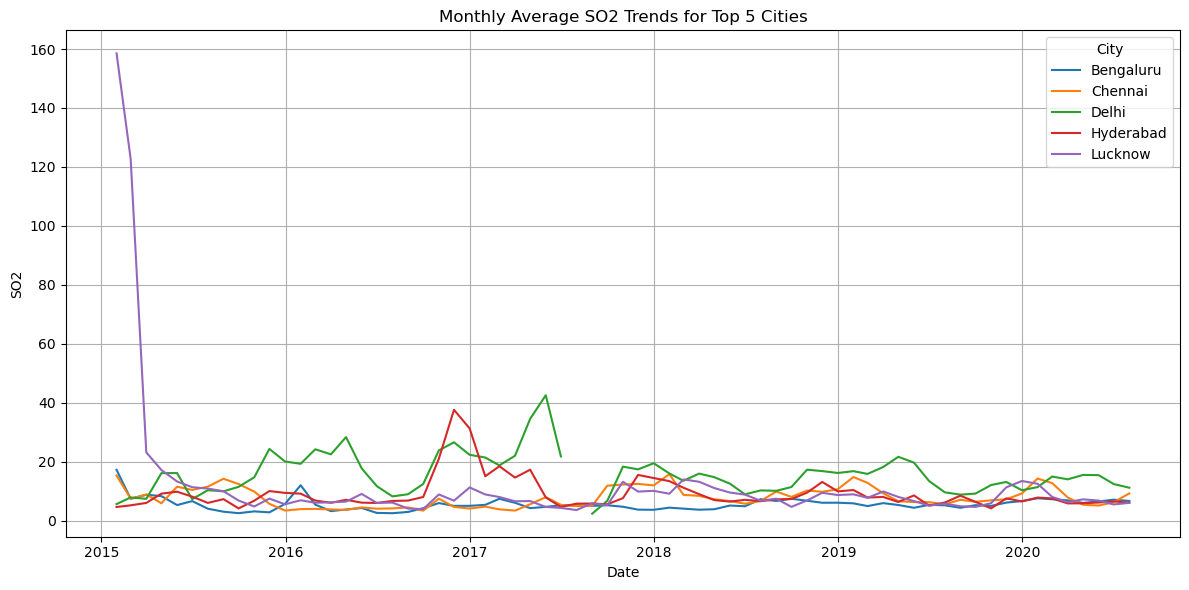

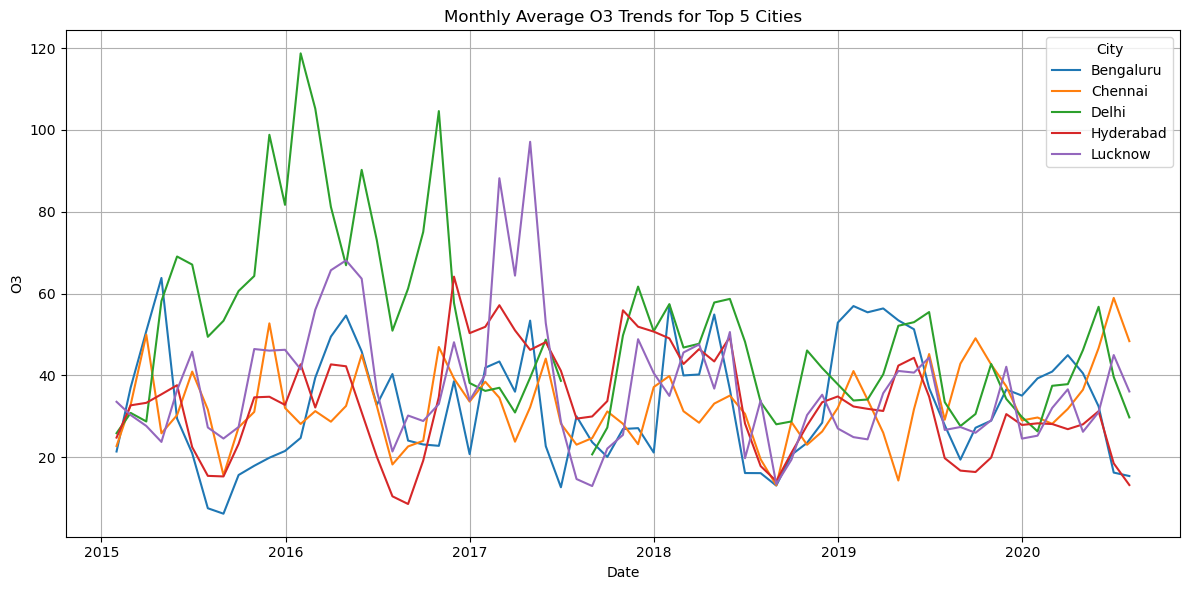

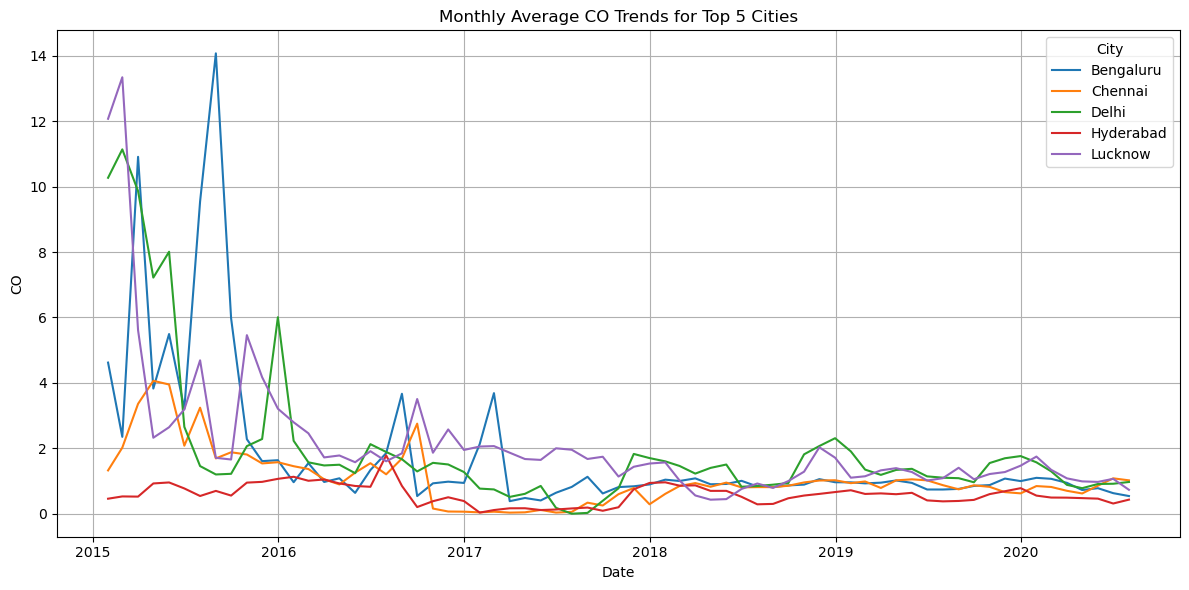

In [ ]:
# draw the trend of each pollutant for the top 5 cities
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO']
top_cities = city_day.groupby('City')['AQI'].count().sort_values(ascending=False).head(5).index.tolist()
top_cities_days = city_day[city_day['City'].isin(top_cities)]


for pollutant in pollutants:
    plt.figure(figsize=(12, 6))
    pollutant_data = top_cities_days.pivot_table(values=pollutant, index='Date', columns='City').resample('M').mean()
    for city in pollutant_data.columns:
        plt.plot(pollutant_data.index, pollutant_data[city], label=city)
    plt.title(f'Monthly Average {pollutant} Trends for Top 5 Cities')
    plt.xlabel('Date')
    plt.ylabel(pollutant)
    plt.legend(title='City', loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

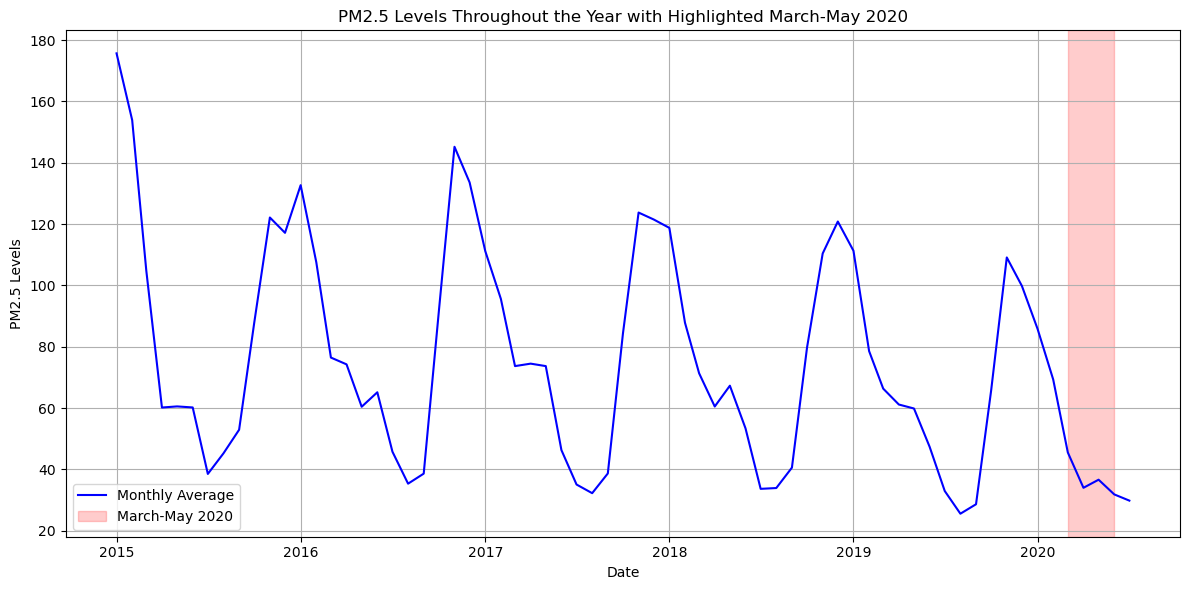

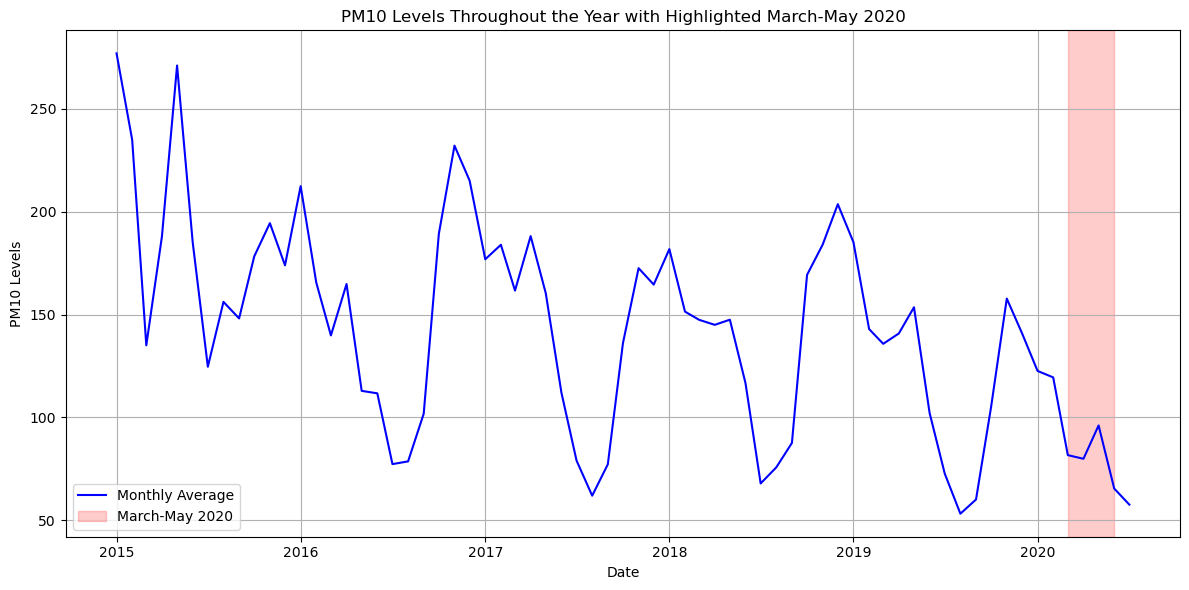

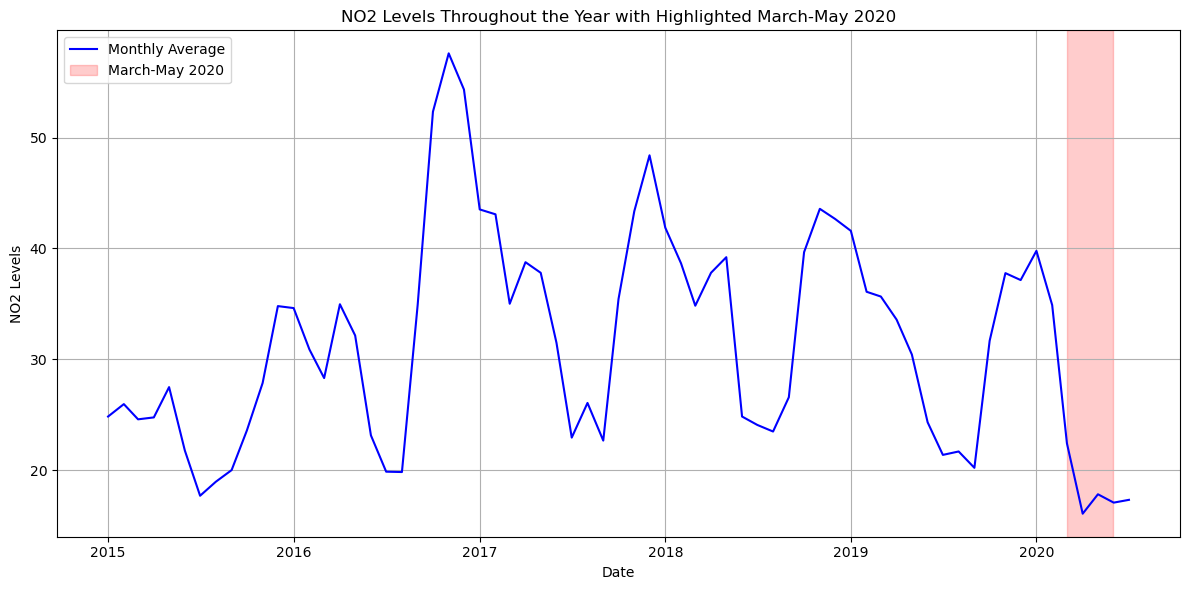

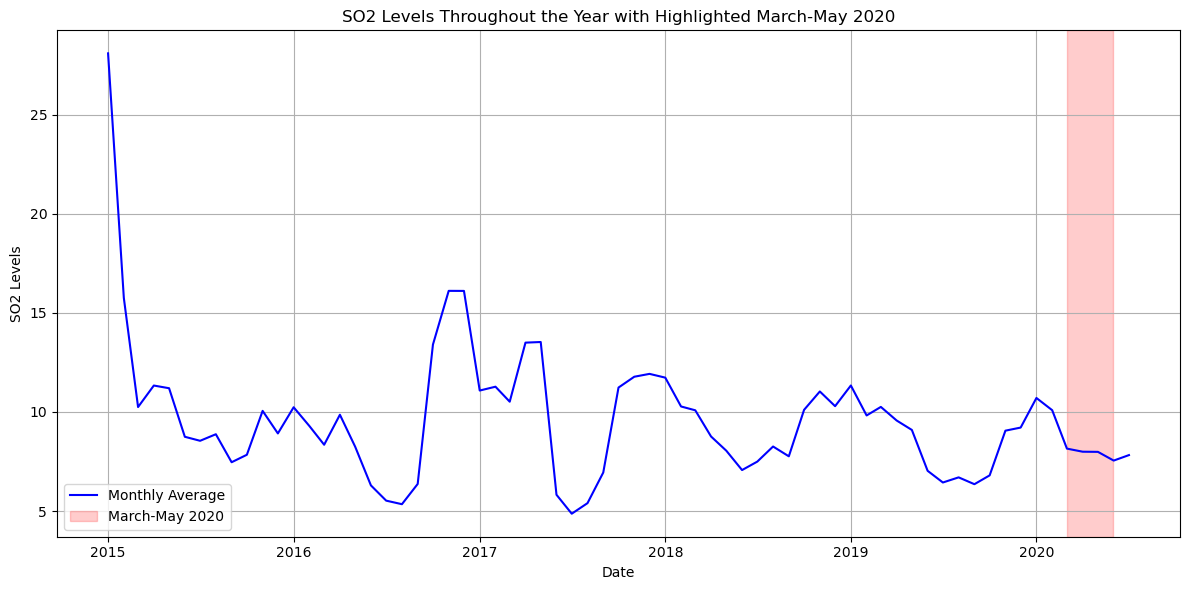

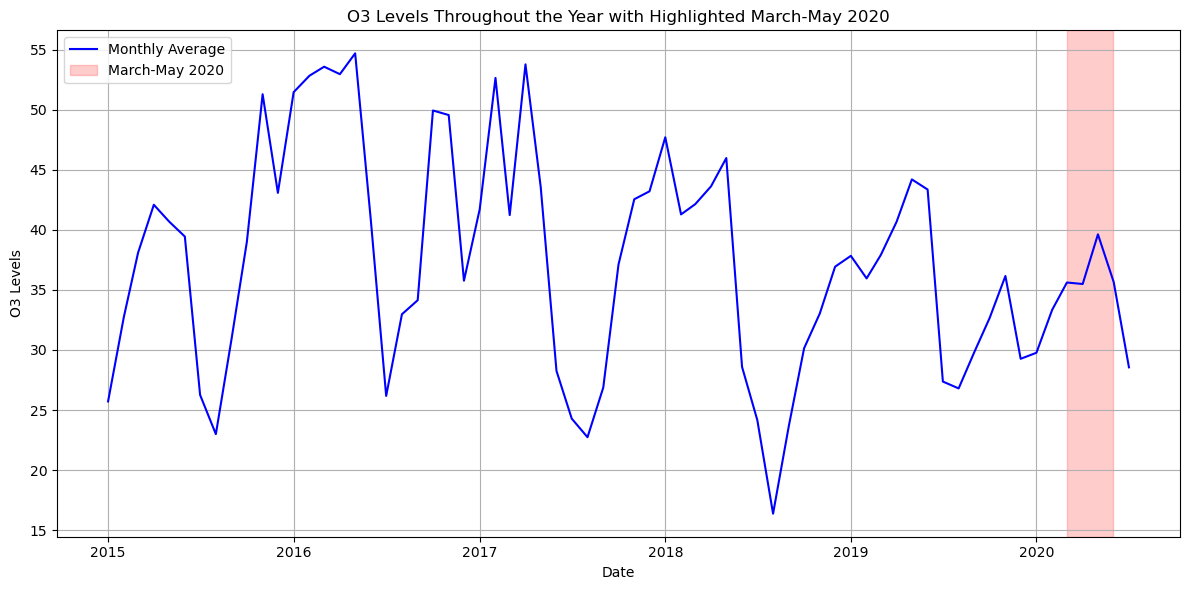

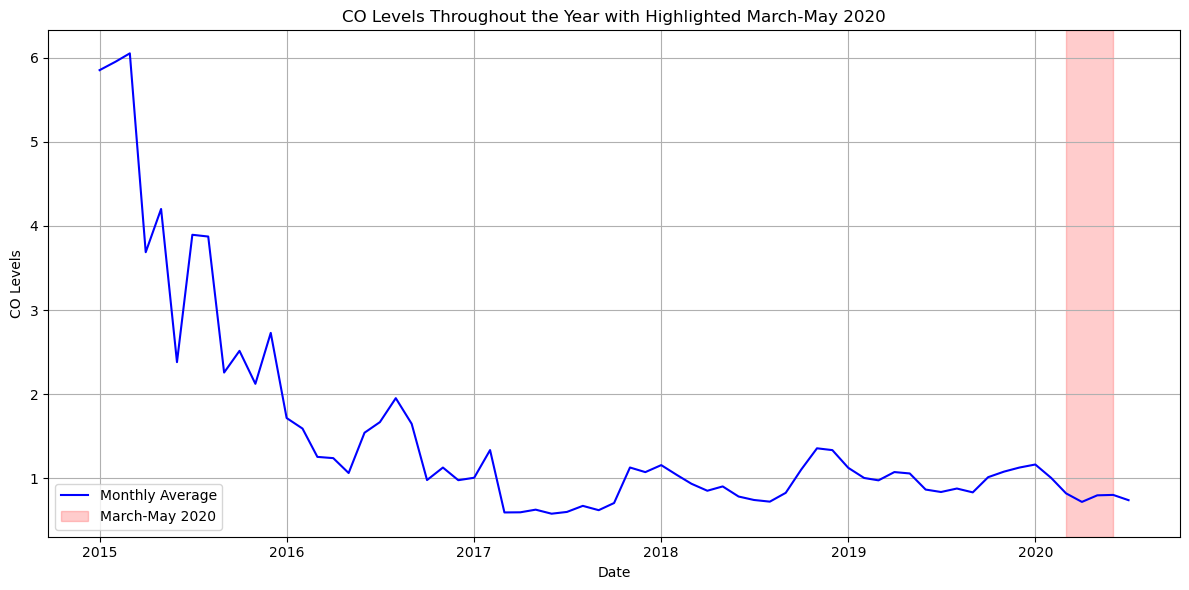

In [ ]:
# draw the trend of each pollutant for the top 5 cities with highlighted March-May 2020
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO']
for pollutant in pollutants:
    plt.figure(figsize=(12, 6))

    monthly_data = top_cities_days.groupby(city_day['Date'].dt.to_period('M'))[pollutant].mean()
    monthly_data.index = monthly_data.index.to_timestamp()
    plt.plot(monthly_data.index, monthly_data, label='Monthly Average', color='blue')
    plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-05-31'), color='red', alpha=0.2, label='March-May 2020')
    plt.title(f'{pollutant} Levels Throughout the Year with Highlighted March-May 2020')
    plt.xlabel('Date')
    plt.ylabel(f'{pollutant} Levels')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

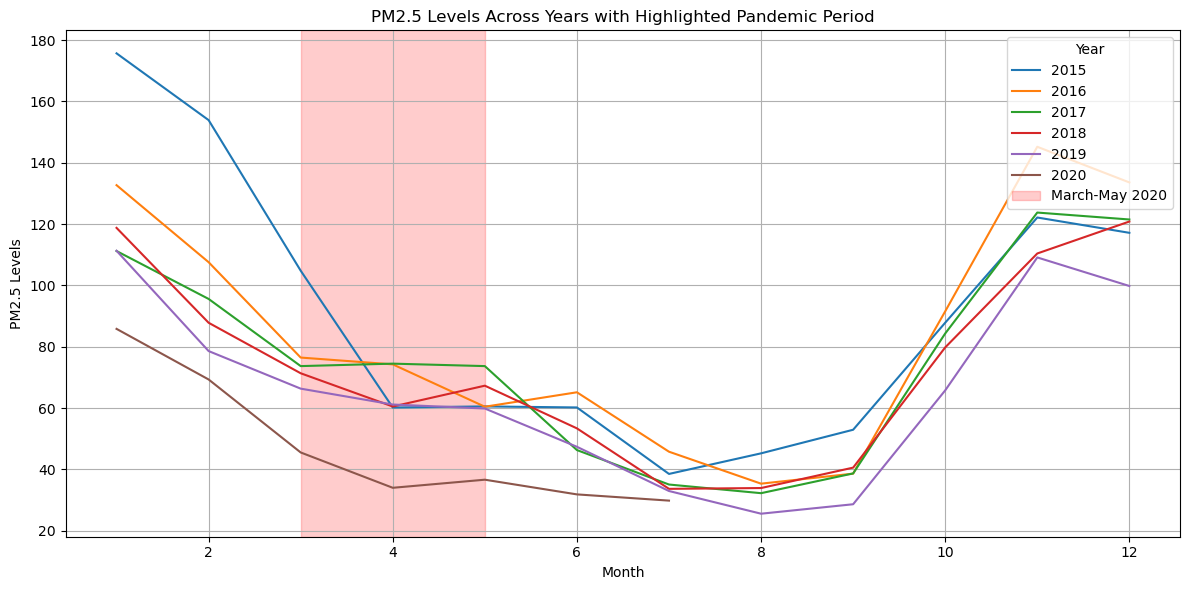

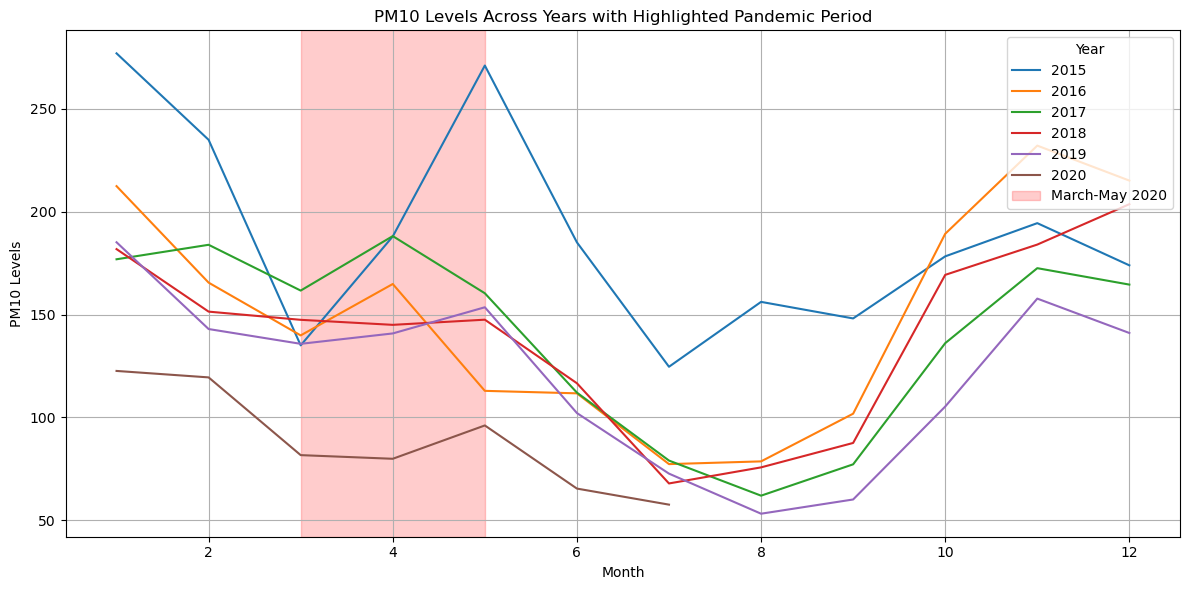

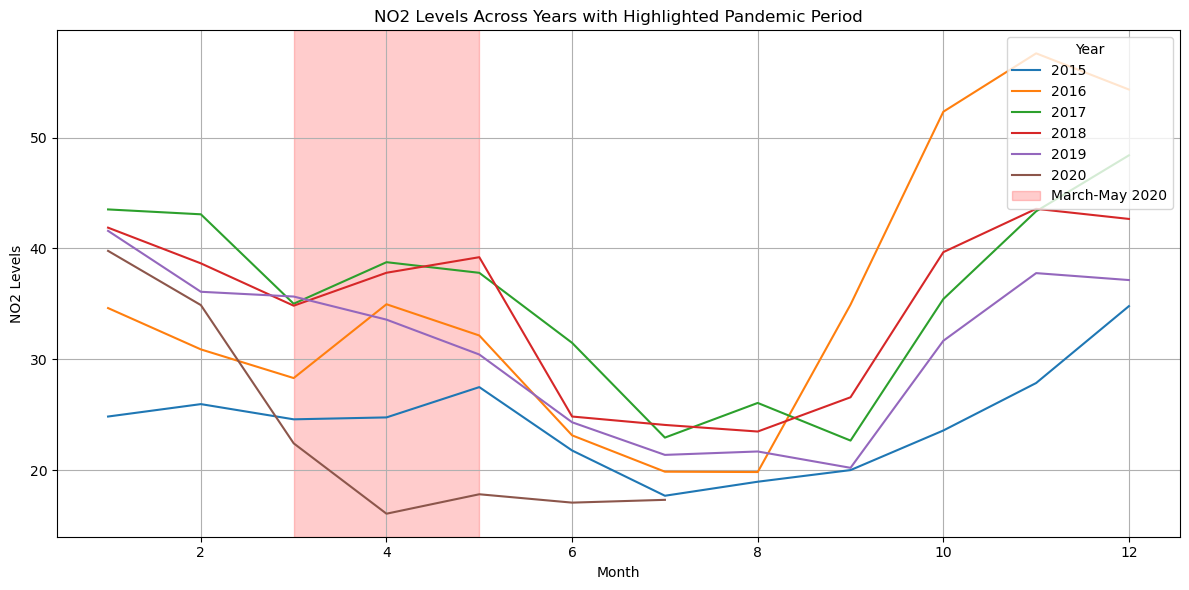

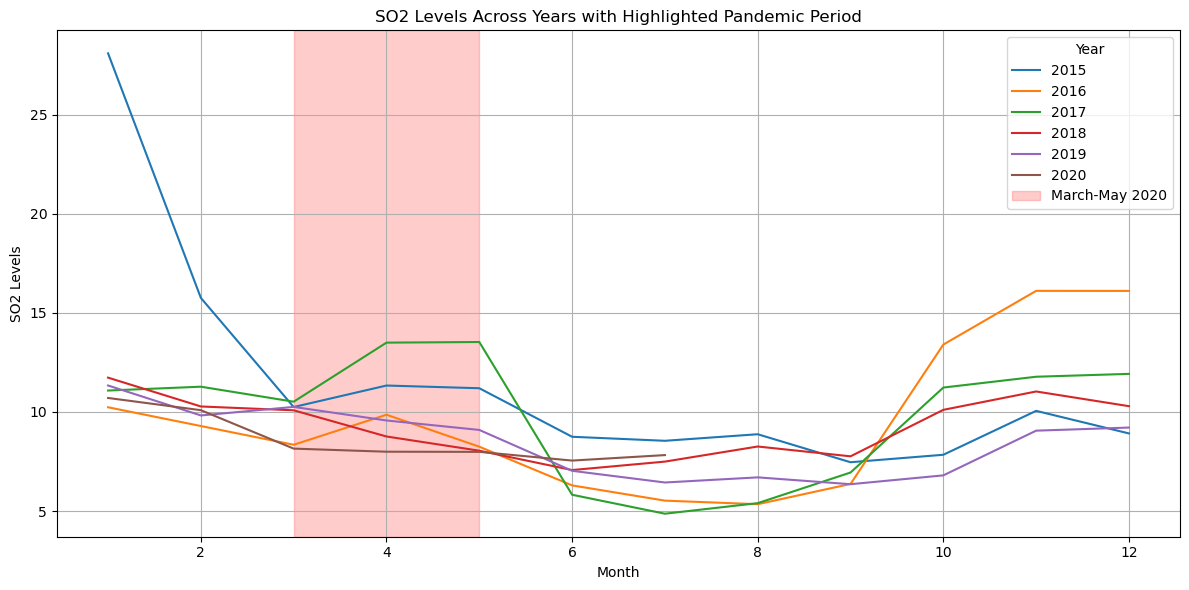

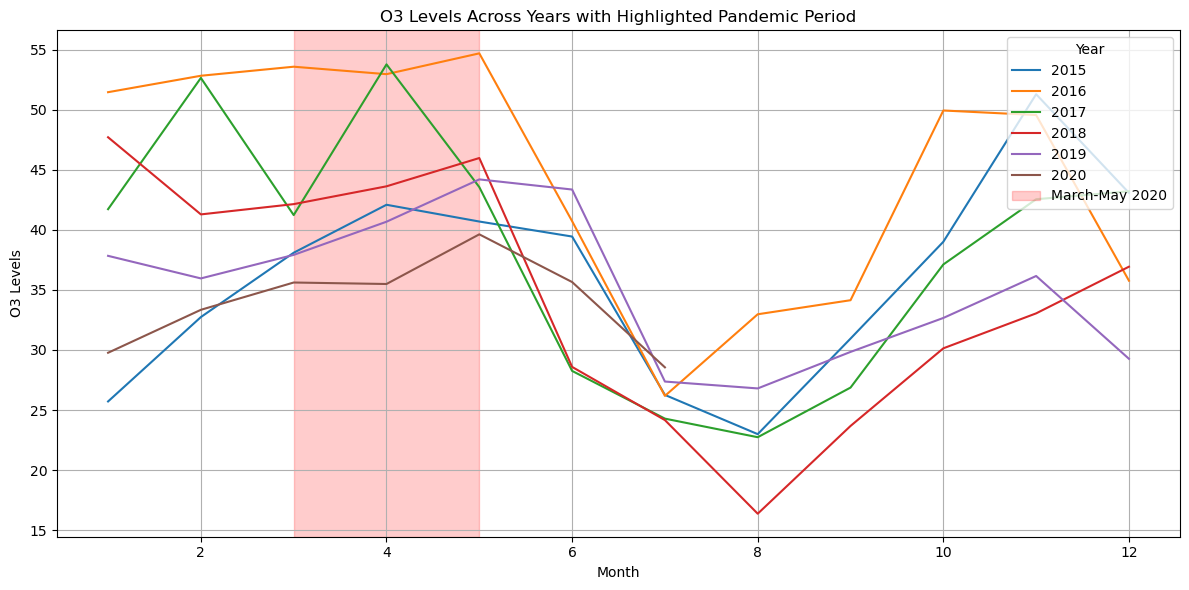

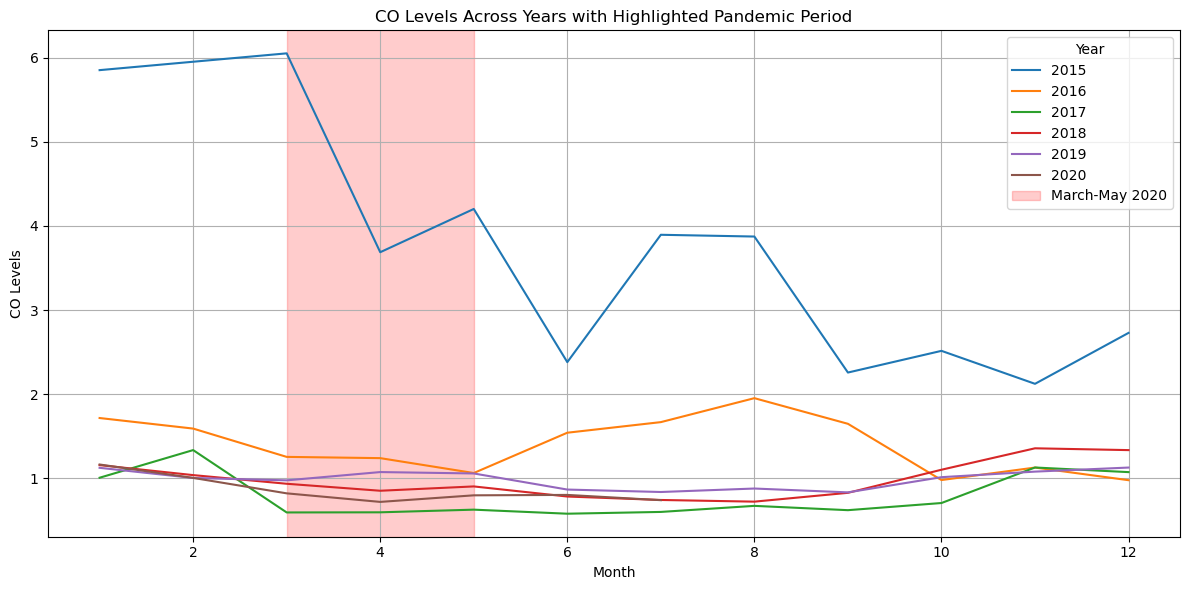

In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO']
for pollutant in pollutants:
    plt.figure(figsize=(12, 6))
    yearly_data = top_cities_days.groupby([city_day['Date'].dt.year, city_day['Date'].dt.month])[pollutant].mean().unstack(level=0)
    for year in yearly_data.columns:
        plt.plot(yearly_data.index, yearly_data[year], label=str(year))

    plt.axvspan(3, 5, color='red', alpha=0.2, label='March-May 2020')
    
    plt.title(f'{pollutant} Levels Across Years with Highlighted Pandemic Period')
    plt.xlabel('Month')
    plt.ylabel(f'{pollutant} Levels')
    plt.legend(title='Year', loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Percentage Change in Pollutants (2020 vs 2015-2019):
O3      -17.796147
SO2     -20.956274
NO2     -43.050094
PM2.5   -43.297504
PM10    -44.343551
CO      -53.553047
dtype: float64


/var/folders/q3/vfx4bm394rs2n1kx5pjqrq8w0000gn/T/ipykernel_1420/1971519268.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_2020_spring = top_cities_days[(city_day['Date'].dt.year == 2020) & (city_day['Date'].dt.month.isin([3, 4, 5]))]
/var/folders/q3/vfx4bm394rs2n1kx5pjqrq8w0000gn/T/ipykernel_1420/1971519268.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_others_spring = top_cities_days[(city_day['Date'].dt.year < 2020) & (city_day['Date'].dt.month.isin([3, 4, 5]))]


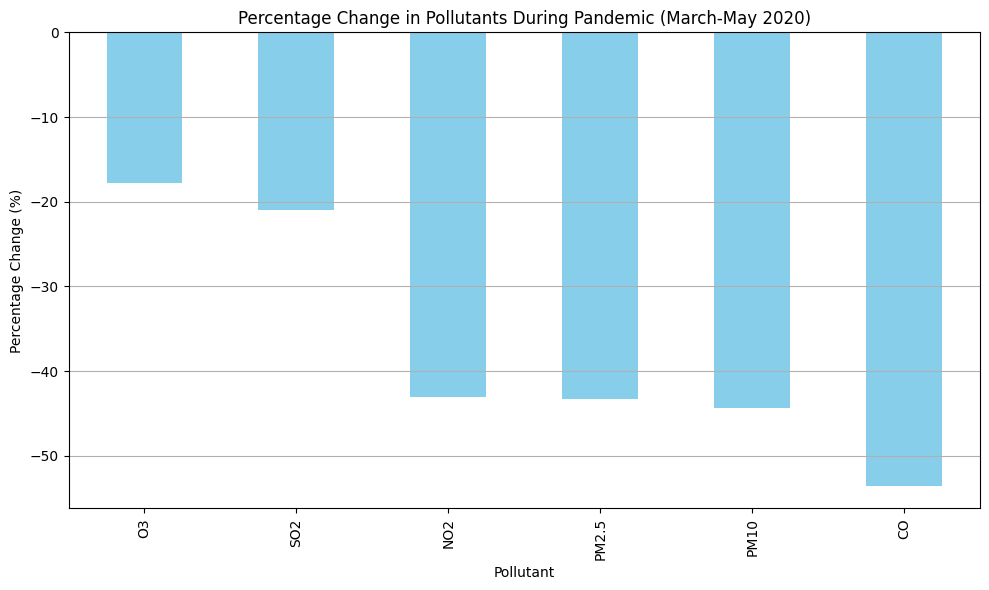

In [ ]:
data_2020_spring = top_cities_days[(city_day['Date'].dt.year == 2020) & (city_day['Date'].dt.month.isin([3, 4, 5]))]
data_others_spring = top_cities_days[(city_day['Date'].dt.year < 2020) & (city_day['Date'].dt.month.isin([3, 4, 5]))]

data_others_mean = data_others_spring[pollutants].mean()
data_2020_mean = data_2020_spring[pollutants].mean()
change = (data_2020_mean - data_others_mean) / data_others_mean * 100
print('Percentage Change in Pollutants (2020 vs 2015-2019):')
print(change.sort_values(ascending=False))

# Plot the percentage change
plt.figure(figsize=(10, 6))
change.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Percentage Change in Pollutants During Pandemic (March-May 2020)')
plt.xlabel('Pollutant')
plt.ylabel('Percentage Change (%)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()